
# FD03 — Spatial Forest-Loss Pattern Analysis

## Objective
Analyze where recorded forest-loss pixels are concentrated and
measure the sizes of connected loss patches.

## Dataset
- Hansen Global Forest Change, version 2023 v1.11
- treecover2000: baseline canopy cover
- lossyear: recorded tree-cover loss year, 2001–2023

## Research questions
1. Is recorded loss spatially concentrated or widely distributed?
2. How does the distribution of connected patch sizes look?
3. How does applying a baseline canopy threshold change the
   spatial pattern of the recorded loss?

## Important limitations
- Recorded tree-cover loss does not automatically mean permanent
  deforestation or illegal activity.
- The dataset's own loss-year layer is not independent ground truth.
- Connected-patch results depend on the connectivity rule and
  raster resolution.
- Patch sizes will initially be reported in pixels, not hectares.

In [2]:

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

from scipy import ndimage

BASE_DIR = "/content/forest_disturbance"
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("FD03 folders ready")
print("Data directory:", DATA_DIR)
print("Results directory:", RESULTS_DIR)

FD03 folders ready
Data directory: /content/forest_disturbance/data
Results directory: /content/forest_disturbance/results


In [4]:

import os
import glob
import requests
from tqdm.auto import tqdm

os.makedirs(DATA_DIR, exist_ok=True)

BASE_URL = (
    "https://storage.googleapis.com/"
    "earthenginepartners-hansen/GFC-2023-v1.11/"
)

TREECOVER_NAME = (
    "Hansen_GFC-2023-v1.11_treecover2000_20N_080E.tif"
)
LOSSYEAR_NAME = (
    "Hansen_GFC-2023-v1.11_lossyear_20N_080E.tif"
)

def locate_file(filename):
    # First check the expected FD03 data folder.
    expected = os.path.join(DATA_DIR, filename)
    if os.path.isfile(expected) and os.path.getsize(expected) > 0:
        return expected

    # Then search the previous FD01/FD02 folders.
    matches = glob.glob(
        os.path.join(BASE_DIR, "**", filename),
        recursive=True
    )
    for path in matches:
        if os.path.isfile(path) and os.path.getsize(path) > 0:
            return path

    return None


def download_file(filename):
    existing = locate_file(filename)
    if existing:
        print("Using existing file:", existing)
        return existing

    url = BASE_URL + filename
    destination = os.path.join(DATA_DIR, filename)
    temporary = destination + ".part"

    print("Downloading:", filename)
    print("Source:", url)

    with requests.get(
        url, stream=True, timeout=(30, 180)
    ) as response:
        response.raise_for_status()
        total = int(response.headers.get("content-length", 0))

        with open(temporary, "wb") as f:
            progress = tqdm(
                total=total if total > 0 else None,
                unit="B",
                unit_scale=True,
                desc=filename[:25]
            )

            for chunk in response.iter_content(
                chunk_size=1024 * 1024
            ):
                if chunk:
                    f.write(chunk)
                    progress.update(len(chunk))

            progress.close()

    if not os.path.exists(temporary) or os.path.getsize(temporary) == 0:
        raise RuntimeError("Download produced an empty file: " + filename)

    os.replace(temporary, destination)
    print("Download complete:", destination)
    return destination


TREECOVER_PATH = download_file(TREECOVER_NAME)
LOSSYEAR_PATH = download_file(LOSSYEAR_NAME)

print("\nBoth input paths are ready.")
print("Tree cover:", TREECOVER_PATH)
print("Loss year:", LOSSYEAR_PATH)

Downloading: Hansen_GFC-2023-v1.11_treecover2000_20N_080E.tif
Source: https://storage.googleapis.com/earthenginepartners-hansen/GFC-2023-v1.11/Hansen_GFC-2023-v1.11_treecover2000_20N_080E.tif


Hansen_GFC-2023-v1.11_tre:   0%|          | 0.00/88.1M [00:00<?, ?B/s]

Download complete: /content/forest_disturbance/data/Hansen_GFC-2023-v1.11_treecover2000_20N_080E.tif
Downloading: Hansen_GFC-2023-v1.11_lossyear_20N_080E.tif
Source: https://storage.googleapis.com/earthenginepartners-hansen/GFC-2023-v1.11/Hansen_GFC-2023-v1.11_lossyear_20N_080E.tif


Hansen_GFC-2023-v1.11_los:   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Download complete: /content/forest_disturbance/data/Hansen_GFC-2023-v1.11_lossyear_20N_080E.tif

Both input paths are ready.
Tree cover: /content/forest_disturbance/data/Hansen_GFC-2023-v1.11_treecover2000_20N_080E.tif
Loss year: /content/forest_disturbance/data/Hansen_GFC-2023-v1.11_lossyear_20N_080E.tif


In [5]:

import rasterio

with rasterio.open(TREECOVER_PATH) as tree_src, \
     rasterio.open(LOSSYEAR_PATH) as loss_src:

    print("TREECOVER")
    print("Shape:", tree_src.height, tree_src.width)
    print("CRS:", tree_src.crs)
    print("Transform:", tree_src.transform)
    print("Bounds:", tree_src.bounds)
    print("NoData:", tree_src.nodata)

    print("\nLOSSYEAR")
    print("Shape:", loss_src.height, loss_src.width)
    print("CRS:", loss_src.crs)
    print("Transform:", loss_src.transform)
    print("Bounds:", loss_src.bounds)
    print("NoData:", loss_src.nodata)

    aligned = (
        tree_src.crs == loss_src.crs
        and tree_src.transform == loss_src.transform
        and tree_src.width == loss_src.width
        and tree_src.height == loss_src.height
    )

print("\nExact spatial alignment:", aligned)

if not aligned:
    raise ValueError(
        "The rasters are not aligned. Stop here; "
        "do not compare their pixels until alignment is resolved."
    )

TREECOVER
Shape: 40000 40000
CRS: EPSG:4326
Transform: | 0.00, 0.00, 80.00|
| 0.00,-0.00, 20.00|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=80.0, bottom=10.0, right=90.0, top=20.0)
NoData: None

LOSSYEAR
Shape: 40000 40000
CRS: EPSG:4326
Transform: | 0.00, 0.00, 80.00|
| 0.00,-0.00, 20.00|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=80.0, bottom=10.0, right=90.0, top=20.0)
NoData: None

Exact spatial alignment: True


In [6]:

from rasterio.enums import Resampling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage

SAMPLE_SIZE = 2000

with rasterio.open(TREECOVER_PATH) as src:
    treecover = src.read(
        1,
        out_shape=(SAMPLE_SIZE, SAMPLE_SIZE),
        resampling=Resampling.nearest
    )

with rasterio.open(LOSSYEAR_PATH) as src:
    lossyear = src.read(
        1,
        out_shape=(SAMPLE_SIZE, SAMPLE_SIZE),
        resampling=Resampling.nearest
    )

# Valid data ranges for this dataset version.
# Zero is a valid value in both layers, so do not remove it
# merely because metadata may report NoData as zero.
valid = (
    np.isfinite(treecover)
    & np.isfinite(lossyear)
    & (treecover >= 0)
    & (treecover <= 100)
    & (lossyear >= 0)
    & (lossyear <= 23)
)

recorded_loss = valid & (lossyear > 0)
canopy_30_loss = recorded_loss & (treecover >= 30)

print("Sample shape:", treecover.shape)
print("Valid sampled pixels:", int(valid.sum()))
print("Sampled pixels with recorded loss:", int(recorded_loss.sum()))
print("Recorded-loss sampled pixels with canopy >=30%:",
      int(canopy_30_loss.sum()))

Sample shape: (2000, 2000)
Valid sampled pixels: 4000000
Sampled pixels with recorded loss: 13611
Recorded-loss sampled pixels with canopy >=30%: 7940


In [7]:

def summarize_patches(binary_mask, label):
    # 8-neighbour connectivity: edges and corners connect pixels.
    structure = np.ones((3, 3), dtype=np.uint8)
    labels, count = ndimage.label(
        binary_mask,
        structure=structure
    )

    sizes = (
        np.bincount(labels.ravel())[1:]
        if count > 0
        else np.array([], dtype=np.int64)
    )

    row = {
        "analysis": label,
        "patch_count": int(len(sizes)),
        "total_patch_pixels": int(sizes.sum()) if len(sizes) else 0,
        "median_patch_pixels": float(np.median(sizes)) if len(sizes) else np.nan,
        "mean_patch_pixels": float(np.mean(sizes)) if len(sizes) else np.nan,
        "largest_patch_pixels": int(sizes.max()) if len(sizes) else 0,
        "single_pixel_patches": int((sizes == 1).sum()) if len(sizes) else 0,
        "patches_2_to_10_pixels": int(
            ((sizes >= 2) & (sizes <= 10)).sum()
        ) if len(sizes) else 0,
        "patches_over_10_pixels": int((sizes > 10).sum()) if len(sizes) else 0
    }

    return row, sizes, labels


all_loss_stats, all_loss_sizes, all_loss_labels = summarize_patches(
    recorded_loss, "All recorded loss"
)

canopy_stats, canopy_loss_sizes, canopy_loss_labels = summarize_patches(
    canopy_30_loss, "Recorded loss where baseline canopy >=30%"
)

patch_summary = pd.DataFrame([all_loss_stats, canopy_stats])
display(patch_summary)

summary_path = os.path.join(RESULTS_DIR, "FD03_patch_summary.csv")
patch_summary.to_csv(summary_path, index=False)
print("Saved:", summary_path)

,analysis,patch_count,total_patch_pixels,median_patch_pixels,mean_patch_pixels,largest_patch_pixels,single_pixel_patches,patches_2_to_10_pixels,patches_over_10_pixels
0,All recorded loss,7663,13611,1.0,1.776197,189,5557,2025,81
1,Recorded loss where baseline canopy >=30%,5055,7940,1.0,1.570722,42,3758,1268,29


Saved: /content/forest_disturbance/results/FD03_patch_summary.csv


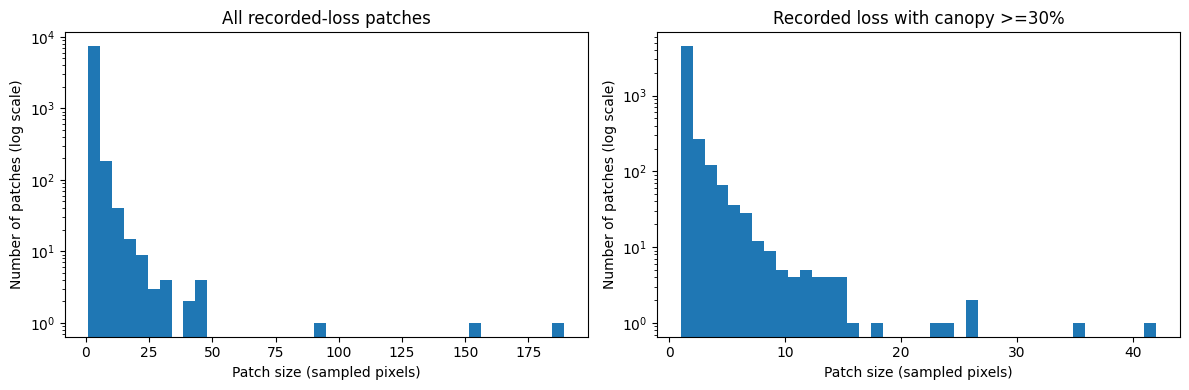

Saved: /content/forest_disturbance/results/FD03_patch_size_distribution.png


In [8]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_items = [
    (axes[0], all_loss_sizes, "All recorded-loss patches"),
    (axes[1], canopy_loss_sizes, "Recorded loss with canopy >=30%")
]

for ax, sizes, title in plot_items:
    if len(sizes):
        ax.hist(sizes, bins=40)
        ax.set_yscale("log")
    else:
        ax.text(
            0.5, 0.5, "No patches found",
            ha="center", va="center",
            transform=ax.transAxes
        )

    ax.set_title(title)
    ax.set_xlabel("Patch size (sampled pixels)")
    ax.set_ylabel("Number of patches (log scale)")

plt.tight_layout()

plot_path = os.path.join(
    RESULTS_DIR, "FD03_patch_size_distribution.png"
)
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)

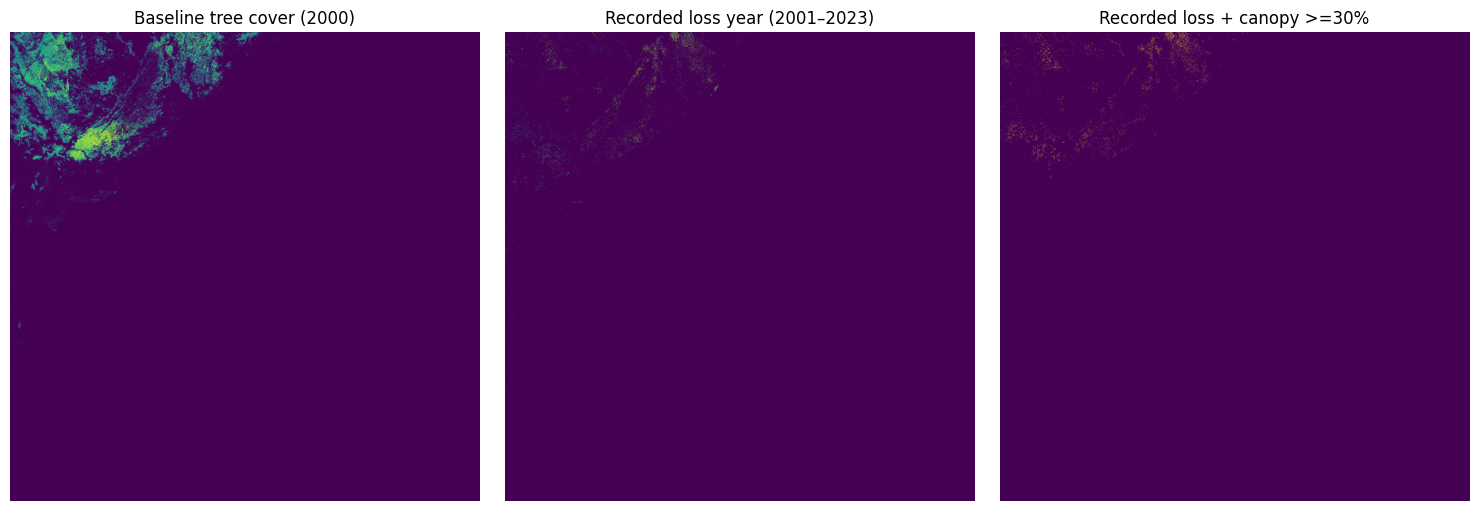

Saved: /content/forest_disturbance/results/FD03_sampled_spatial_maps.png


In [9]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(treecover, vmin=0, vmax=100)
axes[0].set_title("Baseline tree cover (2000)")

axes[1].imshow(lossyear, vmin=0, vmax=23)
axes[1].set_title("Recorded loss year (2001–2023)")

axes[2].imshow(canopy_30_loss)
axes[2].set_title("Recorded loss + canopy >=30%")

for ax in axes:
    ax.axis("off")

plt.tight_layout()

map_path = os.path.join(RESULTS_DIR, "FD03_sampled_spatial_maps.png")
plt.savefig(map_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", map_path)

In [10]:

expected_outputs = [
    "FD03_patch_summary.csv",
    "FD03_patch_size_distribution.png",
    "FD03_sampled_spatial_maps.png"
]

print("FD03 output verification")
for filename in expected_outputs:
    path = os.path.join(RESULTS_DIR, filename)
    print(
        ("OK      " if os.path.isfile(path) else "MISSING "),
        filename
    )

print("\nPatch summary:")
display(pd.read_csv(summary_path))

FD03 output verification
OK       FD03_patch_summary.csv
OK       FD03_patch_size_distribution.png
OK       FD03_sampled_spatial_maps.png

Patch summary:


,analysis,patch_count,total_patch_pixels,median_patch_pixels,mean_patch_pixels,largest_patch_pixels,single_pixel_patches,patches_2_to_10_pixels,patches_over_10_pixels
0,All recorded loss,7663,13611,1.0,1.776197,189,5557,2025,81
1,Recorded loss where baseline canopy >=30%,5055,7940,1.0,1.570722,42,3758,1268,29


In [11]:

year_rows = []

for year_value in range(1, 24):
    year_mask = valid & (lossyear == year_value)

    year_rows.append({
        "year": 2000 + year_value,
        "loss_pixels": int(year_mask.sum()),
        "loss_pixels_canopy_ge_30": int(
            (year_mask & (treecover >= 30)).sum()
        )
    })

year_df = pd.DataFrame(year_rows)

year_csv = os.path.join(RESULTS_DIR, "FD03_loss_by_year.csv")
year_df.to_csv(year_csv, index=False)

display(year_df)
print("Saved:", year_csv)

,year,loss_pixels,loss_pixels_canopy_ge_30
0,2001,166,131
1,2002,231,180
2,2003,309,275
3,2004,273,225
4,2005,310,261
5,2006,383,302
6,2007,434,337
7,2008,587,469
8,2009,592,475
9,2010,202,164


Saved: /content/forest_disturbance/results/FD03_loss_by_year.csv


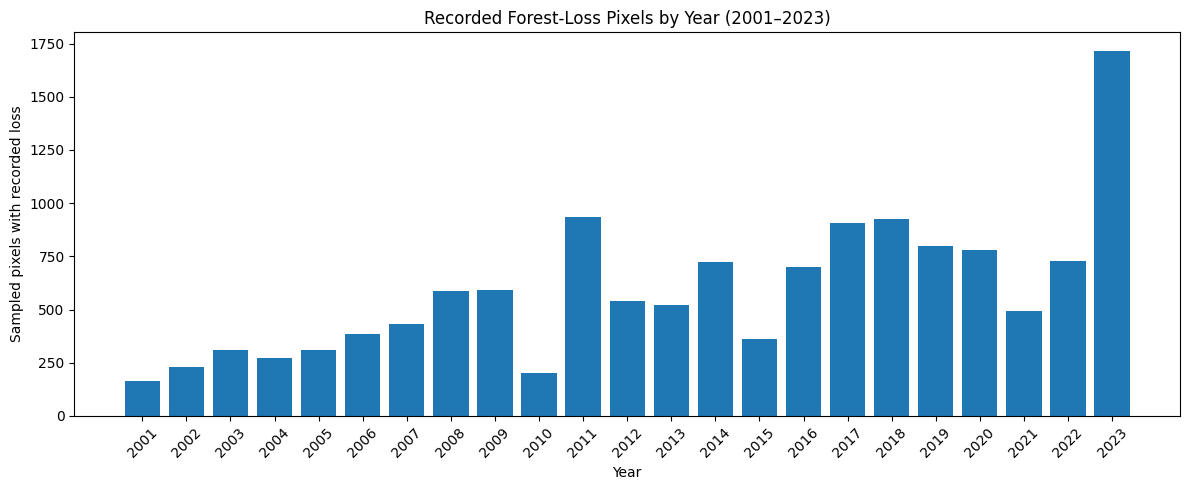

Saved: /content/forest_disturbance/results/FD03_loss_by_year.png


In [12]:

plt.figure(figsize=(12, 5))

plt.bar(year_df["year"], year_df["loss_pixels"])
plt.xlabel("Year")
plt.ylabel("Sampled pixels with recorded loss")
plt.title("Recorded Forest-Loss Pixels by Year (2001–2023)")
plt.xticks(year_df["year"], rotation=45)
plt.tight_layout()

year_plot = os.path.join(RESULTS_DIR, "FD03_loss_by_year.png")
plt.savefig(year_plot, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", year_plot)

In [13]:

threshold_rows = []

for threshold in [10, 30, 50]:
    selected = recorded_loss & (treecover >= threshold)

    stats, sizes, _ = summarize_patches(
        selected,
        f"Canopy >= {threshold}%"
    )

    threshold_rows.append({
        "canopy_threshold_percent": threshold,
        "selected_loss_pixels": int(selected.sum()),
        "connected_patch_count": stats["patch_count"],
        "median_patch_size_pixels": stats["median_patch_pixels"],
        "largest_patch_size_pixels": stats["largest_patch_pixels"]
    })

threshold_df = pd.DataFrame(threshold_rows)

threshold_csv = os.path.join(
    RESULTS_DIR, "FD03_threshold_patch_comparison.csv"
)
threshold_df.to_csv(threshold_csv, index=False)

display(threshold_df)
print("Saved:", threshold_csv)

,canopy_threshold_percent,selected_loss_pixels,connected_patch_count,median_patch_size_pixels,largest_patch_size_pixels
0,10,9585,5892,1.0,48
1,30,7940,5055,1.0,42
2,50,5579,3775,1.0,22


Saved: /content/forest_disturbance/results/FD03_threshold_patch_comparison.csv


In [14]:

all_stats = all_loss_stats
canopy_stats = canopy_stats

report = f"""# FD03 — Spatial Forest-Loss Pattern Analysis

## Experiment status
Executed on the sampled Hansen Global Forest Change raster.
Results below are computed from the current notebook run.

## Data and processing
- Dataset: Hansen Global Forest Change, version 2023 v1.11
- Tile: 20N_080E
- Analysis resolution: {treecover.shape[0]} x {treecover.shape[1]} sampled pixels
- Valid sampled pixels: {int(valid.sum()):,}
- Recorded-loss sampled pixels: {int(recorded_loss.sum()):,}
- Recorded-loss sampled pixels with baseline canopy >=30%:
  {int(canopy_30_loss.sum()):,}
- Patch connectivity: 8-neighbour connectivity

## Connected-patch results

### All recorded-loss pixels
- Patch count: {all_stats["patch_count"]:,}
- Median patch size (pixels): {all_stats["median_patch_pixels"]}
- Mean patch size (pixels): {all_stats["mean_patch_pixels"]}
- Largest patch (pixels): {all_stats["largest_patch_pixels"]:,}

### Recorded loss with baseline canopy >=30%
- Patch count: {canopy_stats["patch_count"]:,}
- Median patch size (pixels): {canopy_stats["median_patch_pixels"]}
- Mean patch size (pixels): {canopy_stats["mean_patch_pixels"]}
- Largest patch (pixels): {canopy_stats["largest_patch_pixels"]:,}

## Interpretation
These statistics describe the spatial pattern of recorded loss in a
downsampled sample of the selected tile. They do not establish that
loss was illegal, human-caused, permanent, or independently verified.

The canopy threshold is an exploratory filter, not a universal
definition of forest. Patch counts and sizes depend on sampling
resolution and the 8-neighbour connectivity rule.

## Outputs
- FD03_patch_summary.csv
- FD03_patch_size_distribution.png
- FD03_sampled_spatial_maps.png
- FD03_loss_by_year.csv
- FD03_loss_by_year.png
- FD03_threshold_patch_comparison.csv

## Validation limitation
The loss-year layer belongs to the same dataset as the baseline
canopy layer. This is a spatial consistency analysis, not independent
ground-truth validation or a claim of predictive accuracy.
"""

report_path = os.path.join(RESULTS_DIR, "FD03_summary.md")

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print("Saved:", report_path)
print(report)

Saved: /content/forest_disturbance/results/FD03_summary.md
# FD03 — Spatial Forest-Loss Pattern Analysis

## Experiment status
Executed on the sampled Hansen Global Forest Change raster.
Results below are computed from the current notebook run.

## Data and processing
- Dataset: Hansen Global Forest Change, version 2023 v1.11
- Tile: 20N_080E
- Analysis resolution: 2000 x 2000 sampled pixels
- Valid sampled pixels: 4,000,000
- Recorded-loss sampled pixels: 13,611
- Recorded-loss sampled pixels with baseline canopy >=30%:
  7,940
- Patch connectivity: 8-neighbour connectivity

## Connected-patch results

### All recorded-loss pixels
- Patch count: 7,663
- Median patch size (pixels): 1.0
- Mean patch size (pixels): 1.7761973117577972
- Largest patch (pixels): 189

### Recorded loss with baseline canopy >=30%
- Patch count: 5,055
- Median patch size (pixels): 1.0
- Mean patch size (pixels): 1.5707220573689415
- Largest patch (pixels): 42

## Interpretation
These statistics describe the sp

In [15]:

expected_outputs = [
    "FD03_patch_summary.csv",
    "FD03_patch_size_distribution.png",
    "FD03_sampled_spatial_maps.png",
    "FD03_loss_by_year.csv",
    "FD03_loss_by_year.png",
    "FD03_threshold_patch_comparison.csv",
    "FD03_summary.md"
]

verification_rows = []

for filename in expected_outputs:
    path = os.path.join(RESULTS_DIR, filename)

    verification_rows.append({
        "file": filename,
        "exists": os.path.isfile(path),
        "size_bytes": (
            os.path.getsize(path)
            if os.path.isfile(path)
            else 0
        )
    })

verification_df = pd.DataFrame(verification_rows)
display(verification_df)

verification_path = os.path.join(
    RESULTS_DIR, "FD03_output_verification.csv"
)
verification_df.to_csv(verification_path, index=False)

print("Verification saved:", verification_path)

if not verification_df["exists"].all():
    print("Some outputs are missing. Review the cells above.")
else:
    print("All expected FD03 outputs exist.")

,file,exists,size_bytes
0,FD03_patch_summary.csv,True,326
1,FD03_patch_size_distribution.png,True,67867
2,FD03_sampled_spatial_maps.png,True,484107
3,FD03_loss_by_year.csv,True,342
4,FD03_loss_by_year.png,True,78376
5,FD03_threshold_patch_comparison.csv,True,179
6,FD03_summary.md,True,1704


Verification saved: /content/forest_disturbance/results/FD03_output_verification.csv
All expected FD03 outputs exist.


In [16]:

if verification_df["exists"].all() and aligned:
    print("FD03 processing completed.")
    print("Spatial alignment check passed.")
    print("Review the patch and threshold tables before writing conclusions.")
else:
    print("FD03 is not yet complete.")
    print("Resolve missing outputs or spatial alignment issues first.")

FD03 processing completed.
Spatial alignment check passed.
Review the patch and threshold tables before writing conclusions.
